# Fisher-Rao Selector

Semantic Pullback explains class `c` by pulling `u = e_c` back through a
softened backward pass. `e_c` is a direction in logit space, and the pullback
treats that space as Euclidean.

It isn't. The logits parameterise `p = softmax(z)`, and the natural metric on
distributions is Fisher-Rao. So re-express `e_c` in that metric first:

```
u = G(z)+ e_c        instead of        u = e_c
```

Nothing else changes same backward pass, same forward pass.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
torch.set_num_threads(4)
pd.set_option('display.width', 160)

from spx import load_bundle, load_imagenette
from spx.data import IMAGENETTE_NAMES
from spx.dossier import show_maps, summary_table

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bundle = load_bundle('resnet50', device)

x_np, y_np, _ = load_imagenette(n=4, res=224, seed=0)
X = torch.as_tensor(x_np, device=device)
Y = torch.as_tensor(y_np, device=device)
titles = [IMAGENETTE_NAMES[int(v)] for v in y_np]
titles

['gas pump', 'chain saw', 'gas pump', 'French horn']

## The metric

`G(z) = diag(p) - p pT`, which is also the Hessian of `logsumexp`. Handy,
because the two get computed by completely unrelated code paths, so it makes
a free sanity check.

In [2]:
from spx.selectors import fisher_rao_matrix

torch.manual_seed(0)
z = torch.randn(7, dtype=torch.float64) * 3
p = z.softmax(-1)

H = torch.autograd.functional.hessian(lambda t: torch.logsumexp(t, -1), z)
print('max |G - Hess logsumexp| =', float((fisher_rao_matrix(p) - H).abs().max()))

max |G - Hess logsumexp| = 4.336808689942018e-19


## Two things break if you do it naively

**1. `G` is singular.** softmax is shift-invariant, so `G @ 1 = 0`. Damping with
`+eps I` gives that direction eigenvalue `eps`, so the inverse *amplifies* it by
`1/eps` the opposite of what a pseudo-inverse should do. Fix: centre `u`
first, which projects it out of the null space.

In [3]:
from spx.selectors import fisher_rao_selector

zb, tgt = z.float()[None], torch.tensor([0])
rows = []
for eps in (1e-2, 1e-4, 1e-6, 1e-8):
    ok = fisher_rao_selector(zb, tgt, p_floor=0.0, eps=eps, project_gauge=True)
    bad = fisher_rao_selector(zb, tgt, p_floor=0.0, eps=eps,
                              project_gauge=False, normalise=False)
    rows.append({'eps': eps, 'centred': float(ok.abs().max()),
                 'not centred': float(bad.abs().max())})
pd.DataFrame(rows)

,eps,centred,not centred
0,1.000000e-02,0.561831,3.491142e+01
1,1.000000e-04,0.811394,1.840095e+03
2,1.000000e-06,0.922393,1.433958e+05
3,1.000000e-08,0.887529,1.677722e+07


**2. The tail takes over.** On a 1000-way head most classes have tiny `p`. Their
Fisher curvature is ~0, so `G+ ~ diag(1/p)` blows them up. Without a floor on
`p`, most of the selector's mass ends up on classes the network already wrote
off.

This is worth stating clearly because it is the opposite of the intuition:
**the Fisher-Rao selector does not measure uncertainty.** It amplifies
written-off classes, and the floor is what stops it.

In [4]:
with torch.no_grad():
    zc = bundle.hard(X[:1])
p_real = zc.softmax(-1)[0]
tgt0 = Y[:1]

floor = 1e-3
tail = p_real < floor
print(f'{int(tail.sum())} of {p_real.numel()} classes sit below the floor '
      f'(they hold {float(p_real[tail].sum()):.1%} of the probability)\n')

for f in (0.0, floor):
    u = fisher_rao_selector(zc, tgt0, p_floor=f, eps=1e-3)[0].abs()
    print(f'p_floor={f:<7} '
          f'selector mass on target: {float(u[Y[0]] / u.sum()):6.2%}   '
          f'on those classes: {float(u[tail].sum() / u.sum()):6.2%}')

962 of 1000 classes sit below the floor (they hold 57.5% of the probability)



p_floor=0.0     selector mass on target:  3.48%   on those classes: 83.26%
p_floor=0.001   selector mass on target: 29.08%   on those classes: 49.88%


## Maps

Both fixes in. Costs one extra `O(C)` solve on top of the ordinary pullback.

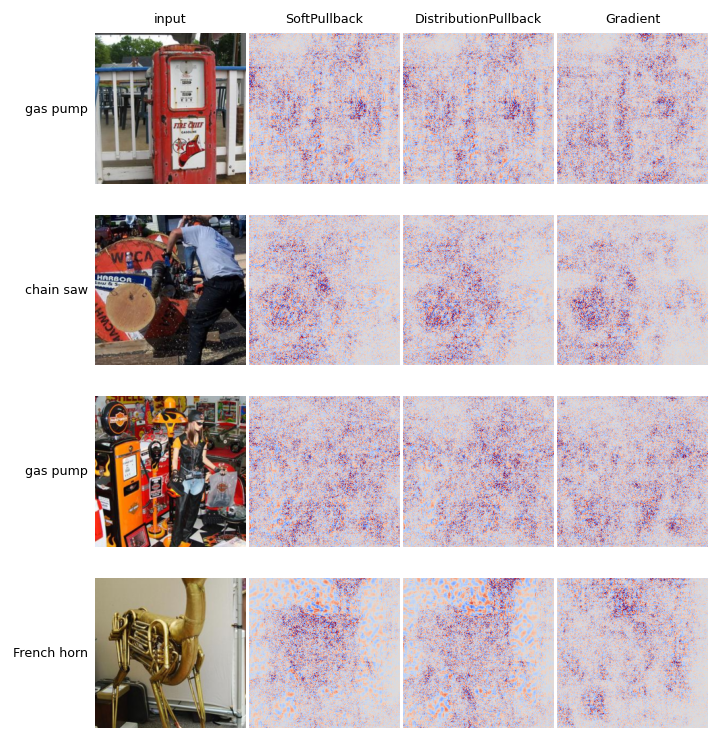

In [5]:
from spx.dossier import attributions_for

A = attributions_for(bundle, X, Y, {
    'SoftPullback': {},
    'DistributionPullback': {'p_floor': 1e-3, 'eps': 1e-3},   # = Fisher-Rao selector
    'Gradient': {},
})
show_maps(X, A, titles=titles)
plt.show()

## Does it help

ResNet-50, 200 Imagenette validation images, the paper's metric suite.
`RandomLogit` = how much the map changes if you ask about a random class
instead. Lower is better; it's the target-specificity metric.

In [6]:
tab = summary_table('resnet50', 200)
tab[['RandomLogit', 'FaithfulnessCorrelation', 'FaithfulnessEstimate', 'MaxSensitivity']] \
   .sort_values('RandomLogit').head(6).round(4)

metric,RandomLogit,FaithfulnessCorrelation,FaithfulnessEstimate,MaxSensitivity
method,,,,
DistributionPullback,-0.059,0.073,0.281,0.411
Gradient,-0.026,0.014,0.384,1.030
InputXGradient,-0.020,-0.034,-0.295,1.092
SoftPullback,-0.018,0.072,0.515,0.401
GradientShap,-0.005,-0.037,-0.460,2.935
IntegratedGradients,-0.003,-0.019,-0.355,0.741


Best `RandomLogit` of all 19 methods, at a stability (`MaxSensitivity` 0.411)
indistinguishable from plain Soft Pullback's 0.401. It pays for that on
`FaithfulnessEstimate`: 0.281 against 0.515.

So: **the most target-specific explanation in the suite, not a general win.**

## Where it stops working

Everything below the floor is clamped to the same `p_eff`, so the
preconditioner multiplies those coordinates by the same constant and the
selector collapses back to `e_c`. Below the floor this method *is* Soft
Pullback.

Not a bug, but it bounds the claim: it only does anything for classes the
network actually entertains.

In [7]:
from spx.data import IMAGENETTE_WNIDS
from spx.explainers import DistributionPullback, SoftPullback
import torch.nn.functional as F

sp = SoftPullback(bundle)
dp = DistributionPullback(bundle, p_floor=1e-3, eps=1e-3)

rows = []
for _, c, name in IMAGENETTE_WNIDS:
    t = torch.tensor([c], device=device)
    a1, a2 = dp.attribute(X[:1], t), sp.attribute(X[:1], t)
    rows.append({'target': name, 'p(target)': float(p_real[c]),
                 'below floor': bool(p_real[c] < 1e-3),
                 'cos(FR, Soft)': float(F.cosine_similarity(a1.flatten(1), a2.flatten(1)))})
pd.DataFrame(rows).sort_values('p(target)', ascending=False).round(4)

,target,p(target),below floor,"cos(FR, Soft)"
7,gas pump,0.3797,False,0.977
9,parachute,0.0008,True,1.000
8,golf ball,0.0007,True,1.000
5,French horn,0.0006,True,1.000
1,English springer,0.0006,True,1.000
0,tench,0.0006,True,1.000
6,garbage truck,0.0005,True,1.000
4,church,0.0005,True,1.000
3,chain saw,0.0004,True,1.000
2,cassette player,0.0004,True,1.000
